# 02 - Target Selection & Problem Definition

## Selección de predicciones candidatas y definición del problema de Machine Learning

En este notebook se define formalmente qué problemas de Machine Learning serán trabajados en el proyecto.

Las predicciones evaluadas son:

- `desempeno_bajo` — ¿El empleado tiene bajo desempeño?
- `ausencia_alta_target` — ¿El empleado tiene muchas ausencias?
- `desempeno_categorico` — ¿El desempeño es bajo, medio o alto?
- `riesgo_rotacion` — ¿El empleado tiene riesgo de rotación?
- `desempeno_alto` — ¿El empleado tiene alto desempeño?
- `puntaje_desempeno` — ¿Cuál es el puntaje numérico de desempeño?

Targets finales seleccionados:

1. **Clasificación:** `desempeno_alto`
2. **Regresión:** `puntaje_desempeno`


# Objetivo del notebook

- Definir variables objetivo candidatas en contexto RRHH.
- Revisar distribución de cada target.
- Identificar desbalance, leakage o targets no modelables.
- Comparar modelos base por target.
- Justificar selección final.


# 1. Contexto metodológico

La elección del target es una de las decisiones más importantes del proyecto.

Un target puede ser inadecuado si:

- tiene una sola clase o desbalance extremo;
- es una feature disfrazada de target;
- genera data leakage;
- no tiene relación clara con las variables disponibles.


# 2. Configuración inicial


In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

project_root = r'C:\Users\Arturo\Desktop\Prueba1'
ruta_plots   = os.path.join(project_root, 'results', 'plots')
os.makedirs(ruta_plots, exist_ok=True)


# 3. Carga del dataset


In [2]:
df = pd.read_csv(os.path.join(project_root,
                              'data/05_model_input/dataset_rrhh_limpio.csv'))

print('Dimensiones del dataset:', df.shape)
df.head()


Dimensiones del dataset: (478, 35)


,id_evaluacion,id_empleado,periodo,puntaje_desempeno,competencias_tecnicas,competencias_blandas,evaluador,periodo_num,departamento,cargo,tipo_contrato,jornada,total_dias_ausencia,num_ausencias,promedio_dias_ausencia,max_dias_ausencia,num_capacitaciones,total_horas_capacitacion,promedio_nota_capacitacion,max_nota_capacitacion,ausencia_alta,sin_capacitacion,capacitacion_intensiva,competencia_combinada,eficiencia_capacitacion,brecha_nota_capacitacion,desempeno_bajo,riesgo_rotacion,riesgo_operacional_rrhh,desempeno_alto,total_dias_ausencia_log,num_capacitaciones_log,total_horas_capacitacion_log,riesgo_operacional_rrhh_log,competencia_combinada_log
0,1.0,252.0,2023-S2,3.6,2.2,4.5,Pedro González Rojas,4,Finanzas,Analista,Honorarios,NaN,30.0,3.0,10.0,21.0,1.0,16.0,2.30,2.3,1,0,0,6.7,0.143750,0.00,0,0,1,0,3.433987,0.693147,2.833213,0.693147,2.041220
1,2.0,135.0,2023-S1,2.6,3.7,4.0,Marcela Araya Aguilera,3,Finanzas,Jefe,Plazo Fijo,Completa,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0,1,0,7.7,0.000000,0.00,1,0,2,0,0.000000,0.000000,0.000000,1.098612,2.163323
2,3.0,11.0,2022-S2,5.6,1.9,6.8,Ignacio Castro Pérez,2,Rrhh,Jefe,Plazo Fijo,Completa,11.0,1.0,11.0,11.0,2.0,48.0,2.65,4.1,0,0,0,8.7,0.055208,1.45,0,0,0,1,2.484907,1.098612,3.891820,0.000000,2.272126
3,5.0,148.0,2022-S2,1.4,5.0,6.4,Agustín Muñoz Valenzuela,2,Logística,Director,Plazo Fijo,NaN,21.0,1.0,21.0,21.0,2.0,100.0,2.05,2.8,0,0,1,11.4,0.020500,0.75,1,0,1,0,3.091042,1.098612,4.615121,0.693147,2.517696
4,6.0,80.0,2023-S1,3.2,1.4,5.1,Ignacio Díaz Reyes,3,Ventas,Coordinador,Indefinido,Por Turnos,2.0,1.0,2.0,2.0,1.0,80.0,1.40,1.4,0,0,1,6.5,0.017500,0.00,0,0,0,0,1.098612,0.693147,4.394449,0.000000,2.014903


## Análisis inicial

El dataset contiene **478 filas** a nivel de evaluación e incluye:

- variables de evaluación por periodo (`competencias_tecnicas`, `competencias_blandas`, `puntaje_desempeno`);
- variables del empleado (`departamento`, `cargo`, `tipo_contrato`, `jornada`);
- variables de ausencias y capacitaciones agregadas por empleado;
- variables derivadas de riesgo y feature engineering.


# 4. Creación de targets candidatos


In [3]:
# Target 1: bajo desempeno (P25).
p25 = df['puntaje_desempeno'].quantile(0.25)
df['desempeno_bajo'] = (df['puntaje_desempeno'] <= p25).astype(int)

# Target 2: ausencia alta como target.
p75_aus = df['total_dias_ausencia'].quantile(0.75)
df['ausencia_alta_target'] = (df['total_dias_ausencia'] >= p75_aus).astype(int)

# Target 3: desempeno categorico (3 clases).
p33 = df['puntaje_desempeno'].quantile(0.33)
p66 = df['puntaje_desempeno'].quantile(0.66)
df['desempeno_categorico'] = np.select(
    [df['puntaje_desempeno'] <= p33, df['puntaje_desempeno'] <= p66],
    [0, 1], default=2
)

# Target 4: riesgo rotacion (ya existe en el dataset).

# Target 5: alto desempeno (P75) <- TARGET PRINCIPAL.
p75 = df['puntaje_desempeno'].quantile(0.75)
df['desempeno_alto'] = (df['puntaje_desempeno'] >= p75).astype(int)

print(f'Umbrales: P25={p25:.2f} | P75={p75:.2f} | P75_aus={p75_aus:.2f}')


Umbrales: P25=2.60 | P75=5.60 | P75_aus=24.00


## Interpretación de los targets creados

| Target | Tipo | Pregunta que responde |
|---|---|---|
| `desempeno_bajo` | Binaria | ¿El empleado tiene bajo desempeño en este periodo? |
| `ausencia_alta_target` | Binaria | ¿El empleado tiene muchas ausencias? |
| `desempeno_categorico` | Multiclase | ¿El desempeño es bajo, medio o alto? |
| `riesgo_rotacion` | Binaria | ¿El empleado combina alta ausencia y bajo desempeño? |
| `desempeno_alto` | Binaria | ¿El empleado tiene alto desempeño? |
| `puntaje_desempeno` | Regresión | ¿Cuál es el nivel numérico de desempeño? |


# 5. Distribución de targets candidatos


Target: desempeno_bajo


desempeno_bajo
0    354
1    124
Name: count, dtype: int64

desempeno_bajo
0    74.06
1    25.94
Name: % proporcion, dtype: float64

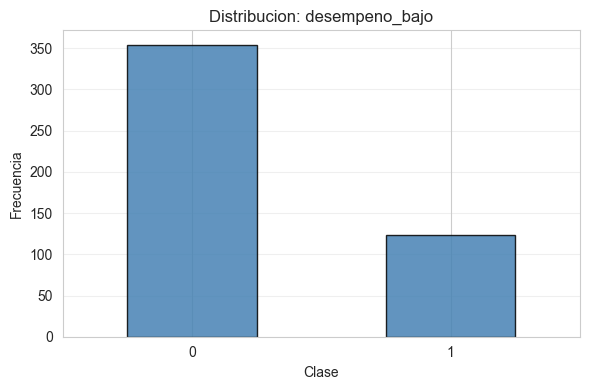


Target: ausencia_alta_target


ausencia_alta_target
0    357
1    121
Name: count, dtype: int64

ausencia_alta_target
0    74.69
1    25.31
Name: % proporcion, dtype: float64

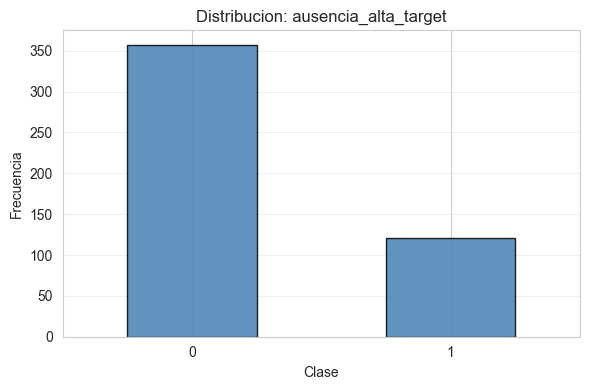


Target: desempeno_categorico


desempeno_categorico
0    171
2    158
1    149
Name: count, dtype: int64

desempeno_categorico
0    35.77
2    33.05
1    31.17
Name: % proporcion, dtype: float64

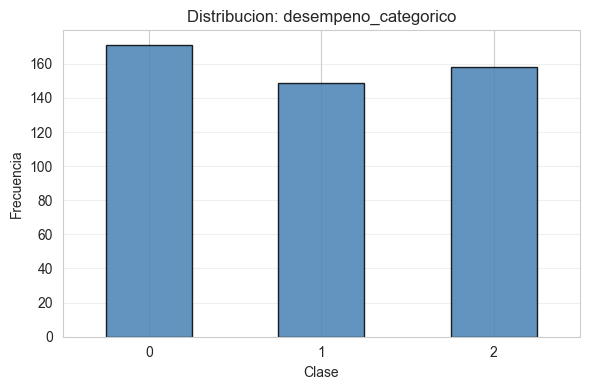


Target: riesgo_rotacion


riesgo_rotacion
0    447
1     31
Name: count, dtype: int64

riesgo_rotacion
0    93.51
1     6.49
Name: % proporcion, dtype: float64

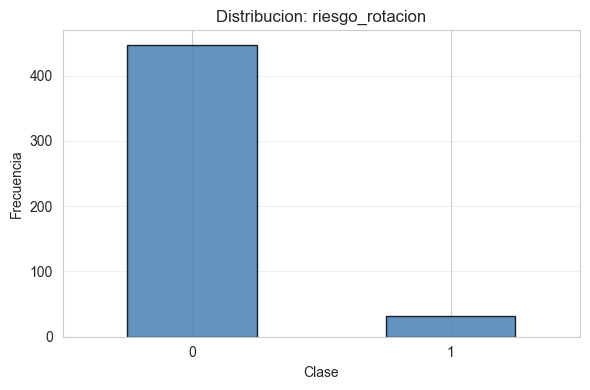


Target: desempeno_alto


desempeno_alto
0    354
1    124
Name: count, dtype: int64

desempeno_alto
0    74.06
1    25.94
Name: % proporcion, dtype: float64

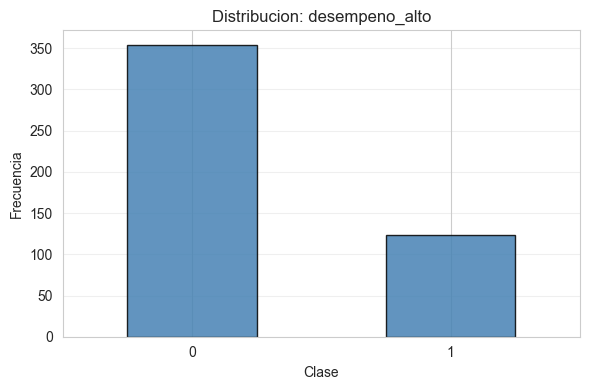

In [4]:
targets_mostrar = [
    'desempeno_bajo', 'ausencia_alta_target',
    'desempeno_categorico', 'desempeno_alto'
]
if 'riesgo_rotacion' in df.columns:
    targets_mostrar.insert(3, 'riesgo_rotacion')

for target in targets_mostrar:
    if target not in df.columns:
        continue
    print('=' * 60)
    print(f'Target: {target}')
    print('=' * 60)
    display(df[target].value_counts())
    display((df[target].value_counts(normalize=True).round(4) * 100).rename('% proporcion'))

    plt.figure(figsize=(6, 4))
    df[target].value_counts().sort_index().plot(
        kind='bar', color='steelblue', edgecolor='black', alpha=0.85)
    plt.title(f'Distribucion: {target}')
    plt.xlabel('Clase')
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=0)
    plt.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    print()


# 6. Preprocesador comun


In [5]:
features_base = [
    'competencias_tecnicas', 'competencias_blandas', 'periodo_num',
    'total_dias_ausencia', 'num_ausencias', 'promedio_dias_ausencia',
    'ausencia_alta',
    'num_capacitaciones', 'total_horas_capacitacion',
    'promedio_nota_capacitacion', 'max_nota_capacitacion',
    'sin_capacitacion', 'capacitacion_intensiva',
    'competencia_combinada', 'eficiencia_capacitacion',
    'riesgo_operacional_rrhh',
    'departamento', 'cargo', 'tipo_contrato', 'jornada',
    'total_dias_ausencia_log', 'num_capacitaciones_log'
]
features_base = [f for f in features_base if f in df.columns]

vars_num = [f for f in features_base if df[f].dtype in ['float64', 'int64']]
vars_cat = [f for f in features_base if df[f].dtype == 'object']

print(f'Features numericas: {len(vars_num)} | Categoricas: {len(vars_cat)}')


Features numericas: 18 | Categoricas: 0


# 7. Evaluacion rapida de targets de clasificacion


In [6]:
def evaluar_target_clf(nombre_target, df, vars_num, vars_cat):
    """Entrena Decision Tree base y retorna metricas para comparar targets."""
    datos = df.dropna(subset=[nombre_target]).copy()
    feats = vars_num + vars_cat
    X = datos[feats]
    y = datos[nombre_target]

    if y.nunique() < 2:
        return {'target': nombre_target, 'n_clases': 1,
                'balance': f'{y.value_counts().to_dict()}',
                'accuracy': None, 'balanced_acc': None,
                'precision': None, 'recall': None, 'f1': None,
                'error': 'Una sola clase'}

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=42,
        stratify=y if y.nunique() <= 5 else None
    )

    pipe = Pipeline([
        ('pre', ColumnTransformer([
            ('n', Pipeline([('i', SimpleImputer(strategy='median')),
                            ('s', StandardScaler())]), vars_num),
            ('c', Pipeline([('i', SimpleImputer(strategy='most_frequent')),
                            ('o', OneHotEncoder(handle_unknown='ignore'))]),
             vars_cat)
        ])),
        ('clf', DecisionTreeClassifier(
            random_state=42, max_depth=5, class_weight='balanced'))
    ])
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)

    avg = 'binary' if y.nunique() == 2 else 'macro'
    vc  = y.value_counts()

    res = {
        'target':       nombre_target,
        'n_clases':     y.nunique(),
        'balance':      str(dict(vc)),
        'accuracy':     round(accuracy_score(y_te, y_pred), 4),
        'balanced_acc': round(balanced_accuracy_score(y_te, y_pred), 4),
        'precision':    round(precision_score(y_te, y_pred,
                              average=avg, zero_division=0), 4),
        'recall':       round(recall_score(y_te, y_pred,
                              average=avg, zero_division=0), 4),
        'f1':           round(f1_score(y_te, y_pred,
                              average=avg, zero_division=0), 4)
    }

    print(f'\n===== {nombre_target} =====')
    print(classification_report(y_te, y_pred, zero_division=0))
    return res


targets_clf = ['desempeno_bajo', 'ausencia_alta_target',
               'desempeno_categorico', 'riesgo_rotacion', 'desempeno_alto']
targets_clf = [t for t in targets_clf if t in df.columns]

resultados_clf = []
for t in targets_clf:
    res = evaluar_target_clf(t, df, vars_num, vars_cat)
    resultados_clf.append(res)



===== desempeno_bajo =====
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        71
           1       0.96      1.00      0.98        25

    accuracy                           0.99        96
   macro avg       0.98      0.99      0.99        96
weighted avg       0.99      0.99      0.99        96


===== ausencia_alta_target =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        72
           1       1.00      1.00      1.00        24

    accuracy                           1.00        96
   macro avg       1.00      1.00      1.00        96
weighted avg       1.00      1.00      1.00        96


===== desempeno_categorico =====
              precision    recall  f1-score   support

           0       0.93      0.74      0.82        34
           1       0.45      0.50      0.48        30
           2       0.47      0.53      0.50        32

    accuracy                    

# 8. Comparacion de targets de clasificacion


,target,n_clases,balance,accuracy,balanced_acc,precision,recall,f1
0,desempeno_bajo,2,"{0: np.int64(354), 1: np.int64(124)}",0.9896,0.9930,0.9615,1.0000,0.9804
1,ausencia_alta_target,2,"{0: np.int64(357), 1: np.int64(121)}",1.0000,1.0000,1.0000,1.0000,1.0000
2,desempeno_categorico,3,"{0: np.int64(171), 2: np.int64(158), 1: np.int...",0.5938,0.5888,0.6176,0.5888,0.5986
3,riesgo_rotacion,2,"{0: np.int64(447), 1: np.int64(31)}",1.0000,1.0000,1.0000,1.0000,1.0000
4,desempeno_alto,2,"{0: np.int64(354), 1: np.int64(124)}",0.5625,0.6783,0.3651,0.9200,0.5227


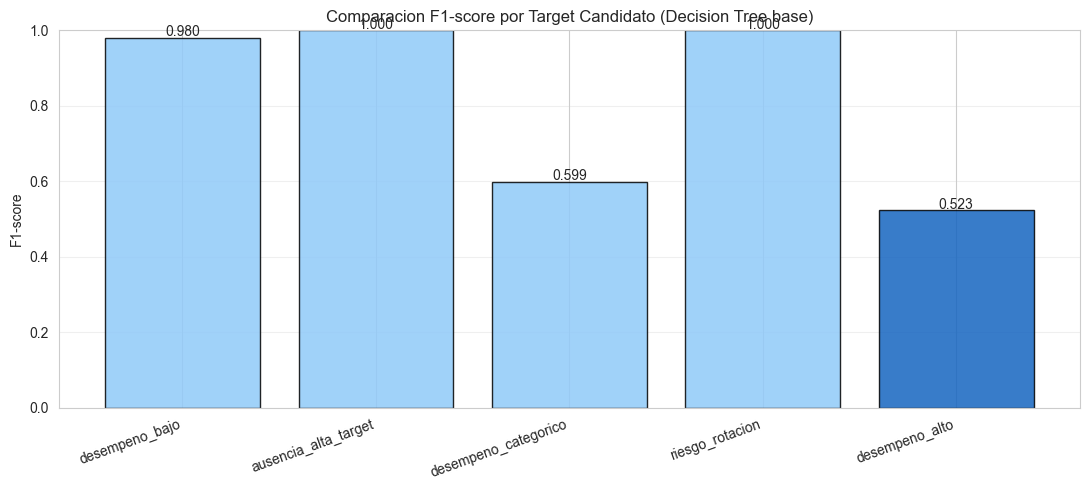

In [7]:
tabla_clf = pd.DataFrame(resultados_clf)
display(tabla_clf)

tabla_valida = tabla_clf.dropna(subset=['f1'])
colores = ['#1565C0' if t == 'desempeno_alto' else '#90CAF9'
           for t in tabla_valida['target']]

plt.figure(figsize=(11, 5))
bars = plt.bar(tabla_valida['target'], tabla_valida['f1'],
               color=colores, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, tabla_valida['f1']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontsize=10)
plt.title('Comparacion F1-score por Target Candidato (Decision Tree base)')
plt.ylabel('F1-score')
plt.ylim(0, 1)
plt.xticks(rotation=20, ha='right')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(ruta_plots, '02_comparacion_targets_clf.png'),
            dpi=150, bbox_inches='tight')
plt.show()


# 9. Evaluacion rapida del target de regresion


Regresion base — puntaje_desempeno (Decision Tree):
  MAE:  1.1793
  RMSE: 2.0005
  R2:   0.2063


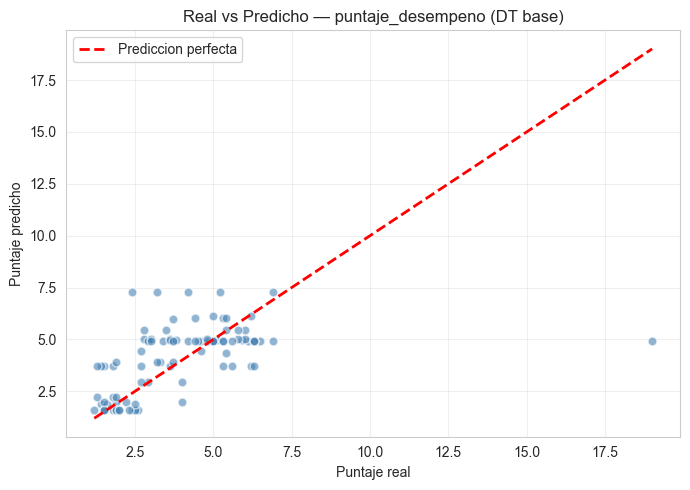

In [8]:
datos_reg = df.dropna(subset=['puntaje_desempeno']).copy()
X_r = datos_reg[vars_num + vars_cat]
y_r = datos_reg['puntaje_desempeno']

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_r, y_r, test_size=0.2, random_state=42
)

pipe_reg = Pipeline([
    ('pre', ColumnTransformer([
        ('n', Pipeline([('i', SimpleImputer(strategy='median')),
                        ('s', StandardScaler())]), vars_num),
        ('c', Pipeline([('i', SimpleImputer(strategy='most_frequent')),
                        ('o', OneHotEncoder(handle_unknown='ignore'))]),
         vars_cat)
    ])),
    ('reg', DecisionTreeRegressor(random_state=42, max_depth=6))
])
pipe_reg.fit(X_tr_r, y_tr_r)
y_pred_r = pipe_reg.predict(X_te_r)

print('Regresion base — puntaje_desempeno (Decision Tree):')
print(f'  MAE:  {mean_absolute_error(y_te_r, y_pred_r):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_te_r, y_pred_r)):.4f}')
print(f'  R2:   {r2_score(y_te_r, y_pred_r):.4f}')

plt.figure(figsize=(7, 5))
plt.scatter(y_te_r, y_pred_r, alpha=0.6, color='steelblue',
            edgecolors='white', s=40)
lim = [min(y_te_r.min(), y_pred_r.min()),
       max(y_te_r.max(), y_pred_r.max())]
plt.plot(lim, lim, 'r--', lw=2, label='Prediccion perfecta')
plt.title('Real vs Predicho — puntaje_desempeno (DT base)')
plt.xlabel('Puntaje real')
plt.ylabel('Puntaje predicho')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ruta_plots, '02_real_vs_predicho_base.png'),
            dpi=150, bbox_inches='tight')
plt.show()


# 10. Justificacion de descarte por target

## `desempeno_bajo` — Descartado
Es el inverso exacto de `desempeno_alto`. Predecir el cuartil inferior tiene menor valor estratégico que identificar talento de alto desempeño para retención y promociones.

## `ausencia_alta_target` — Descartado
Es una feature del modelo usada incorrectamente como target. Predecirla genera circularidad: la misma variable se usa como predictor del desempeño y como objetivo. Sin valor organizacional real.

## `desempeno_categorico` — Descartado
La clasificación en 3 clases añade complejidad técnica (métricas macro menos interpretables, fronteras difusas) sin ventaja real sobre la versión binaria para la toma de decisiones de RRHH.

## `riesgo_rotacion` — Descartado
Combina `ausencia_alta` con `desempeno_bajo`, que deriva de `puntaje_desempeno`. Genera data leakage parcial. La clase positiva es muy minoritaria (pocos empleados combinan ambas condiciones), generando desbalance extremo.


# 11. Tabla resumen de decision


In [9]:
resumen = pd.DataFrame([
    {'target': 'desempeno_bajo',
     'tipo': 'Clasificacion binaria',
     'decision': 'Descartado',
     'motivo': 'Menor valor estrategico; inverso del target seleccionado.'},
    {'target': 'ausencia_alta_target',
     'tipo': 'Clasificacion binaria',
     'decision': 'Descartado',
     'motivo': 'Feature del modelo usada como target; circularidad sin valor predictivo.'},
    {'target': 'desempeno_categorico',
     'tipo': 'Clasificacion multiclase',
     'decision': 'Descartado',
     'motivo': 'Mayor complejidad sin ventaja interpretativa sobre version binaria.'},
    {'target': 'riesgo_rotacion',
     'tipo': 'Clasificacion binaria',
     'decision': 'Descartado',
     'motivo': 'Data leakage parcial; clase positiva muy minoritaria.'},
    {'target': 'desempeno_alto',
     'tipo': 'Clasificacion binaria',
     'decision': 'SELECCIONADO',
     'motivo': 'Mayor valor estrategico; balance 75/25 aceptable; sin leakage.'},
    {'target': 'puntaje_desempeno',
     'tipo': 'Regresion continua',
     'decision': 'SELECCIONADO',
     'motivo': 'Permite estimar intensidad del desempeno y ordenar empleados.'}
])

resumen


,target,tipo,decision,motivo
0,desempeno_bajo,Clasificacion binaria,Descartado,Menor valor estrategico; inverso del target se...
1,ausencia_alta_target,Clasificacion binaria,Descartado,Feature del modelo usada como target; circular...
2,desempeno_categorico,Clasificacion multiclase,Descartado,Mayor complejidad sin ventaja interpretativa s...
3,riesgo_rotacion,Clasificacion binaria,Descartado,Data leakage parcial; clase positiva muy minor...
4,desempeno_alto,Clasificacion binaria,SELECCIONADO,Mayor valor estrategico; balance 75/25 aceptab...
5,puntaje_desempeno,Regresion continua,SELECCIONADO,Permite estimar intensidad del desempeno y ord...


# 12. Decision final del proyecto

## Clasificacion principal — `desempeno_alto`

> ¿Este empleado pertenece al grupo de alto desempeño en este periodo de evaluacion?

Permite generar alertas para decisiones de promocion, capacitacion y retencion de talento.

## Regresion principal — `puntaje_desempeno`

> ¿Cual es el nivel estimado de desempeno de este empleado en este periodo?

Permite asignar un puntaje continuo y ordenar empleados segun su nivel de desempeno esperado.

Ambas predicciones son complementarias: la regresion estima la intensidad y la clasificacion traduce eso en una decision organizacional concreta.


# 13. Conclusiones del notebook

La comparacion mostro que algunos targets no son adecuados:

- `desempeno_bajo`: redundante y menor valor estrategico.
- `ausencia_alta_target`: feature disfrazada de target.
- `desempeno_categorico`: complejidad sin ventaja real.
- `riesgo_rotacion`: data leakage parcial y desbalance extremo.

`desempeno_alto` y `puntaje_desempeno` mostraron mejor comportamiento tecnico y coherencia con el contexto de RRHH.

El proyecto continuara con:

- clasificacion para identificar empleados de alto desempeno;
- regresion para estimar el puntaje continuo de desempeno.
